# FarmTech Solutions — Previsão de rendimento de safra

**FIAP · Inteligência Artificial · Fase 5 — Cap 1: FarmTech na Era da Cloud Computing**

Douglas Felicio da Silva — RM 572312

---

A FarmTech Solutions foi contratada por uma fazenda de 200 hectares que cultiva
quatro produtos diferentes. A pergunta do cliente é direta: *dadas as condições
de solo e clima, quanto vamos colher?*

Este relatório responde essa pergunta em três movimentos:

1. **Análise exploratória** — entender o que a base realmente contém, antes de
   modelar qualquer coisa.
2. **Clusterização** — encontrar tendências de produtividade e cenários
   discrepantes (*outliers*).
3. **Cinco modelos preditivos** — cada um com um algoritmo diferente, avaliados
   com métricas que fazem sentido para o problema.

A conclusão mais importante do trabalho não é o modelo com maior R². É a
descoberta de *por que* o R² alto, nesta base, engana — e o que fazer a
respeito. Essa discussão está na seção final.

In [1]:
# Bibliotecas usadas no relatório inteiro.
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import DBSCAN, KMeans
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error,
                             r2_score, root_mean_squared_error, silhouette_score)
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

# Semente única para todo o notebook: garante que qualquer pessoa que rode este
# arquivo obtenha exatamente os mesmos números citados no texto.
SEMENTE = 42
np.random.seed(SEMENTE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 110)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print("Ambiente pronto.")

Ambiente pronto.


## 1. Os dados

O arquivo `crop_yield.csv` traz 156 registros com quatro variáveis climáticas e
o rendimento medido em toneladas por hectare. Renomeamos as colunas para nomes
curtos em português — o nome original, com unidade e espaços, atrapalha o
código sem acrescentar informação que já não esteja documentada aqui.

In [2]:
CAMINHO = Path("../dados/crop_yield.csv")

# De/para dos nomes originais (com unidade e espaços) para nomes curtos.
COLUNAS = {
    "Crop": "cultura",
    "Precipitation (mm day-1)": "precipitacao",
    "Specific Humidity at 2 Meters (g/kg)": "umidade_especifica",
    "Relative Humidity at 2 Meters (%)": "umidade_relativa",
    "Temperature at 2 Meters (C)": "temperatura",
    "Yield": "rendimento",
}

# Lista usada o notebook inteiro: só as quatro variáveis preditoras climáticas.
CLIMA = ["precipitacao", "umidade_especifica", "umidade_relativa", "temperatura"]

df = pd.read_csv(CAMINHO).rename(columns=COLUNAS)   # carrega e já renomeia
df.head()                                            # confere as cinco primeiras linhas

,cultura,precipitacao,umidade_especifica,umidade_relativa,temperatura,rendimento
0,"Cocoa, beans","2,248.92",17.72,83.40,26.01,11560
1,"Cocoa, beans","1,938.42",17.54,82.11,26.11,11253
2,"Cocoa, beans","2,301.54",17.81,82.79,26.24,9456
3,"Cocoa, beans","2,592.35",17.61,85.07,25.56,9321
4,"Cocoa, beans","2,344.72",17.61,84.12,25.76,8800


In [3]:
# Diagnóstico mínimo antes de qualquer análise: tamanho, buracos e repetições.
print(f"Registros ......... {len(df)}")
print(f"Colunas ........... {df.shape[1]}")
print(f"Valores ausentes .. {int(df.isna().sum().sum())}")   # zero dispensa imputação
print(f"Linhas duplicadas . {int(df.duplicated().sum())}")   # zero dispensa deduplicação
print()
df.info()   # tipos inferidos pelo pandas — confirma que só 'cultura' é texto

Registros ......... 156
Colunas ........... 6
Valores ausentes .. 0
Linhas duplicadas . 0

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cultura             156 non-null    str    
 1   precipitacao        156 non-null    float64
 2   umidade_especifica  156 non-null    float64
 3   umidade_relativa    156 non-null    float64
 4   temperatura         156 non-null    float64
 5   rendimento          156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB


Base pequena e limpa: 156 linhas, nenhum valor ausente, nenhuma duplicata. Isso
dispensa imputação, mas o tamanho — 39 observações por cultura — vai voltar a
aparecer como a principal limitação do trabalho.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
precipitacao,156.00,"2,486.50",289.46,"1,934.62","2,302.99","2,424.55","2,718.08","3,085.79"
umidade_especifica,156.00,18.20,0.29,17.54,18.03,18.27,18.40,18.70
umidade_relativa,156.00,84.74,1.00,82.11,84.12,84.85,85.51,86.10
temperatura,156.00,26.18,0.26,25.56,26.02,26.13,26.30,26.81
rendimento,156.00,"56,153.10","70,421.96","5,249.00","8,327.75","18,871.00","67,518.75","203,399.00"


## 2. Análise exploratória

### 2.1 Quatro culturas em escalas muito diferentes

A primeira coisa a checar é como o rendimento se distribui. E aqui já aparece
algo que decide o desenho do resto do trabalho.

In [5]:
# Estatísticas do rendimento por cultura, ordenadas da menor para a maior média.
resumo = (df.groupby("cultura")["rendimento"]
            .agg(n="count", media="mean", desvio="std", minimo="min", maximo="max")
            .sort_values("media"))

# Coeficiente de variação: o desvio como % da média. É o que permite comparar a
# dispersão entre culturas cujas escalas são muito diferentes.
resumo["coef_variacao_%"] = (resumo["desvio"] / resumo["media"] * 100).round(1)
resumo

,n,media,desvio,minimo,maximo,coef_variacao_%
cultura,,,,,,
"Rubber, natural",39,"7,824.90","1,600.26",5249,10285,20.50
"Cocoa, beans",39,"8,883.13","1,745.03",5765,13056,19.60
"Rice, paddy",39,"32,099.67","4,789.95",24686,42550,14.90
Oil palm fruit,39,"175,804.69","14,919.87",142425,203399,8.50


O óleo de palma rende, em média, **175.805** — vinte vezes mais que a borracha
(**7.825**). Não é uma diferença de grau, é uma diferença de escala. Guarde esse
número: ele é a razão pela qual o R² vai enganar mais adiante.

Já o coeficiente de variação — o desvio como percentual da média — fica entre
8% e 20% em todas as culturas. Ou seja: *dentro* de cada cultura a variação é
modesta e comparável.

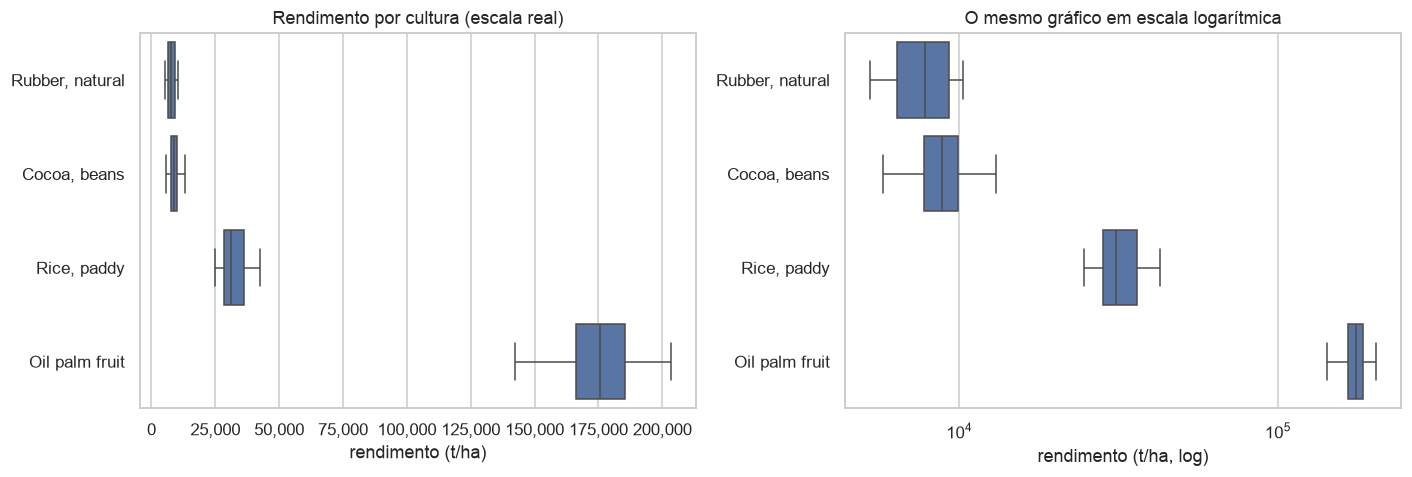

In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.5))

ordem = resumo.index.tolist()   # mantém as culturas ordenadas por média
sns.boxplot(data=df, y="cultura", x="rendimento", order=ordem, ax=eixos[0])
eixos[0].set(title="Rendimento por cultura (escala real)",
             xlabel="rendimento (t/ha)", ylabel="")
eixos[0].xaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")

# Em escala logarítmica as quatro distribuições ficam comparáveis lado a lado.
sns.boxplot(data=df, y="cultura", x="rendimento", order=ordem, ax=eixos[1])
eixos[1].set_xscale("log")
eixos[1].set(title="O mesmo gráfico em escala logarítmica",
             xlabel="rendimento (t/ha, log)", ylabel="")

plt.tight_layout()
plt.show()

### 2.2 As quatro culturas compartilham exatamente o mesmo clima

Ao olhar as linhas do arquivo lado a lado, percebe-se que os valores climáticos
se repetem entre as culturas. Vale conferir isso formalmente, porque muda
completamente o que é possível aprender daqui.

In [7]:
# Reorganiza a base: cada linha vira uma observação climática, com o rendimento
# das quatro culturas naquela mesma condição.
df["obs"] = df.groupby("cultura").cumcount()

clima_por_cultura = df.pivot_table(index="obs", columns="cultura", values=CLIMA)
identicos = all(
    np.allclose(clima_por_cultura[v].nunique(axis=1), 1) for v in CLIMA
)
print(f"As quatro culturas têm os mesmos valores climáticos? {identicos}")
print(f"Condições climáticas distintas na base: {df['obs'].nunique()}")
print(f"Linhas totais: {df['obs'].nunique()} condições x {df['cultura'].nunique()} culturas "
      f"= {df['obs'].nunique() * df['cultura'].nunique()}")

As quatro culturas têm os mesmos valores climáticos? True
Condições climáticas distintas na base: 39
Linhas totais: 39 condições x 4 culturas = 156


Confirmado. A base não tem 156 medições climáticas independentes — tem **39**,
cada uma repetida para as quatro culturas. Isso significa que:

- o volume real de informação climática é quase quatro vezes menor do que o
  número de linhas sugere;
- qualquer divisão treino/teste feita sem cuidado coloca a *mesma* condição
  climática dos dois lados, inflando artificialmente o desempenho;
- a variável `cultura` sozinha carrega quase toda a diferença de rendimento.

Vamos medir esse último ponto.

In [8]:
# Quanto da variância do rendimento é explicada só por saber qual é a cultura?
media_geral = df["rendimento"].mean()
sq_total = ((df["rendimento"] - media_geral) ** 2).sum()
sq_entre = sum(len(g) * (g["rendimento"].mean() - media_geral) ** 2
               for _, g in df.groupby("cultura"))

print(f"R² de um 'modelo' que só conhece a cultura: {sq_entre / sq_total:.4f}")
print(f"Sobra para o clima explicar:               {1 - sq_entre / sq_total:.4f}")

R² de um 'modelo' que só conhece a cultura: 0.9876
Sobra para o clima explicar:               0.0124


**98,76% da variância do rendimento é explicada apenas por qual cultura está
plantada.** Sobra 1,24% para as quatro variáveis climáticas disputarem.

Esse é o achado que organiza todo o resto do relatório.

### 2.3 Correlação: o que o agregado esconde

Como as culturas têm escalas muito distintas mas o mesmo clima, a correlação
calculada sobre a base inteira é praticamente zero. Ela só volta a existir
quando olhamos dentro de cada cultura.

In [9]:
# Correlação de cada variável climática com o rendimento, na base inteira.
correl_global = df[CLIMA + ["rendimento"]].corr()["rendimento"].drop("rendimento")

# A mesma correlação, recalculada dentro de cada cultura separadamente.
correl_interna = pd.DataFrame({
    cultura: g[CLIMA + ["rendimento"]].corr()["rendimento"].drop("rendimento")
    for cultura, g in df.groupby("cultura")
})

# Coloca o agregado na primeira coluna para o contraste ficar imediato.
correl_interna.insert(0, "BASE INTEIRA", correl_global)
correl_interna.round(3)

,BASE INTEIRA,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
precipitacao,0.02,0.17,0.22,0.33,0.10
umidade_especifica,0.01,-0.06,0.07,0.70,-0.43
umidade_relativa,0.00,-0.06,-0.04,0.15,-0.05
temperatura,0.01,-0.01,0.10,0.61,-0.41


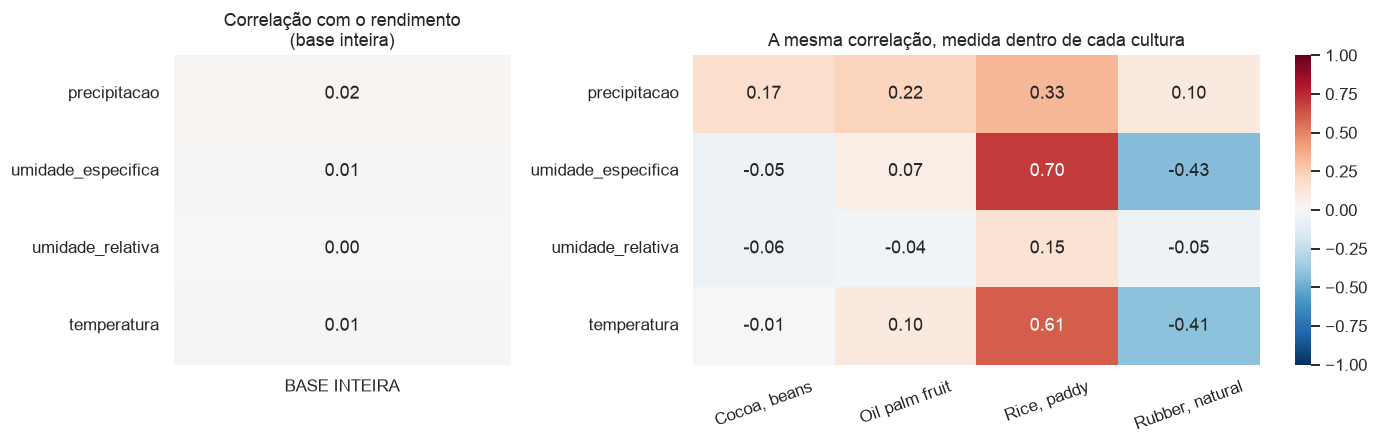

In [10]:
# Dois heatmaps lado a lado. A mesma escala de cor (-1 a 1) nos dois painéis é o
# que torna a comparação honesta: sem isso, o painel da esquerda ganharia cores
# fortes só por ter seus próprios limites.
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.2),
                          gridspec_kw={"width_ratios": [1, 2.1]})

sns.heatmap(correl_interna[["BASE INTEIRA"]], annot=True, fmt=".2f", center=0,
            cmap="RdBu_r", vmin=-1, vmax=1, cbar=False, ax=eixos[0])
eixos[0].set(title="Correlação com o rendimento\n(base inteira)", ylabel="")

sns.heatmap(correl_interna.drop(columns="BASE INTEIRA"), annot=True, fmt=".2f",
            center=0, cmap="RdBu_r", vmin=-1, vmax=1, ax=eixos[1])
eixos[1].set(title="A mesma correlação, medida dentro de cada cultura", ylabel="")
eixos[1].tick_params(axis="x", rotation=20)   # nomes de cultura são longos

plt.tight_layout()
plt.show()

A leitura do painel da direita:

- **Arroz** reage forte e positivamente à umidade específica (**0,70**) e à
  temperatura (**0,61**);
- **Borracha** faz o oposto — quanto mais quente e úmido, *menor* o rendimento
  (**-0,41** e **-0,43**);
- **Cacau** e **óleo de palma** quase não respondem ao clima nesta faixa.

Culturas diferentes reagem em direções opostas. Um modelo único que ignore a
cultura vai simplesmente cancelar esses efeitos — é exatamente o que o painel da
esquerda mostra.

### 2.4 Um alerta: as 39 observações são uma série temporal

O rendimento do arroz cresce quase que linearmente ao longo do arquivo. Se as
linhas estiverem em ordem cronológica — o que o padrão sugere fortemente —,
parte da "correlação com o clima" pode ser apenas tendência compartilhada.

In [11]:
# 'obs' é a posição da medição dentro de cada cultura: um proxy de tempo.
tendencia = pd.DataFrame({
    "rendimento ~ tempo": {c: g["obs"].corr(g["rendimento"])
                           for c, g in df.groupby("cultura")}
})

base_clima = df[df["cultura"] == df["cultura"].iloc[0]]
tendencia_clima = pd.Series(
    {v: base_clima["obs"].corr(base_clima[v]) for v in CLIMA},
    name="variável climática ~ tempo")

print(tendencia.round(3).to_string())
print()
print(tendencia_clima.round(3).to_string())

                 rendimento ~ tempo
Cocoa, beans                   0.10
Oil palm fruit                 0.50
Rice, paddy                    0.91
Rubber, natural               -0.36

precipitacao         0.42
umidade_especifica   0.80
umidade_relativa     0.22
temperatura          0.66


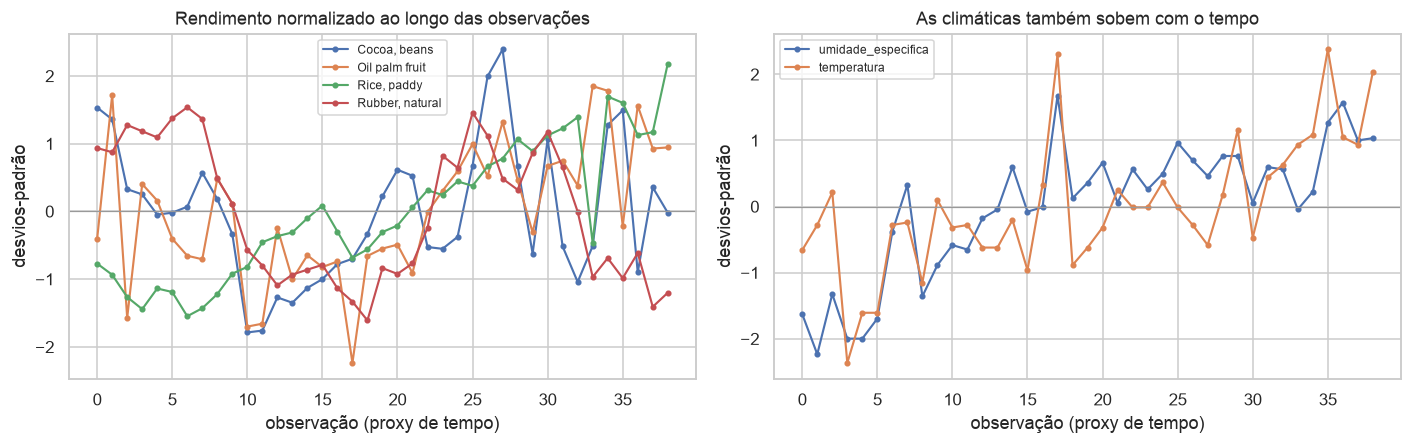

In [12]:
# Duas séries no tempo: rendimento de cada cultura e as próprias climáticas.
# Se as duas subirem juntas, a correlação entre elas pode ser só tendência.
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.2))

for cultura, g in df.groupby("cultura"):
    # Normaliza cada série para que as quatro caibam no mesmo eixo.
    z = (g["rendimento"] - g["rendimento"].mean()) / g["rendimento"].std()
    eixos[0].plot(g["obs"], z, marker="o", ms=3, lw=1.4, label=cultura)
eixos[0].set(title="Rendimento normalizado ao longo das observações",
             xlabel="observação (proxy de tempo)", ylabel="desvios-padrão")
eixos[0].legend(fontsize=8)
eixos[0].axhline(0, color="0.6", lw=0.8)

for v in ["umidade_especifica", "temperatura"]:
    z = (base_clima[v] - base_clima[v].mean()) / base_clima[v].std()
    eixos[1].plot(base_clima["obs"], z, marker="o", ms=3, lw=1.4, label=v)
eixos[1].set(title="As climáticas também sobem com o tempo",
             xlabel="observação (proxy de tempo)", ylabel="desvios-padrão")
eixos[1].legend(fontsize=8)
eixos[1].axhline(0, color="0.6", lw=0.8)

plt.tight_layout()
plt.show()

O arroz tem correlação **0,91** com a posição no arquivo. A umidade específica
tem **0,80** e a temperatura **0,66**. Duas séries que crescem juntas produzem
correlação alta mesmo sem relação causal — é o caso clássico de **correlação
espúria por tendência comum**.

Ou seja: o 0,70 entre umidade específica e rendimento do arroz provavelmente
mede *ganho tecnológico ao longo dos anos*, não efeito do clima. Registramos
isso como limitação e voltamos ao ponto na conclusão.

### 2.5 As variáveis climáticas são redundantes entre si

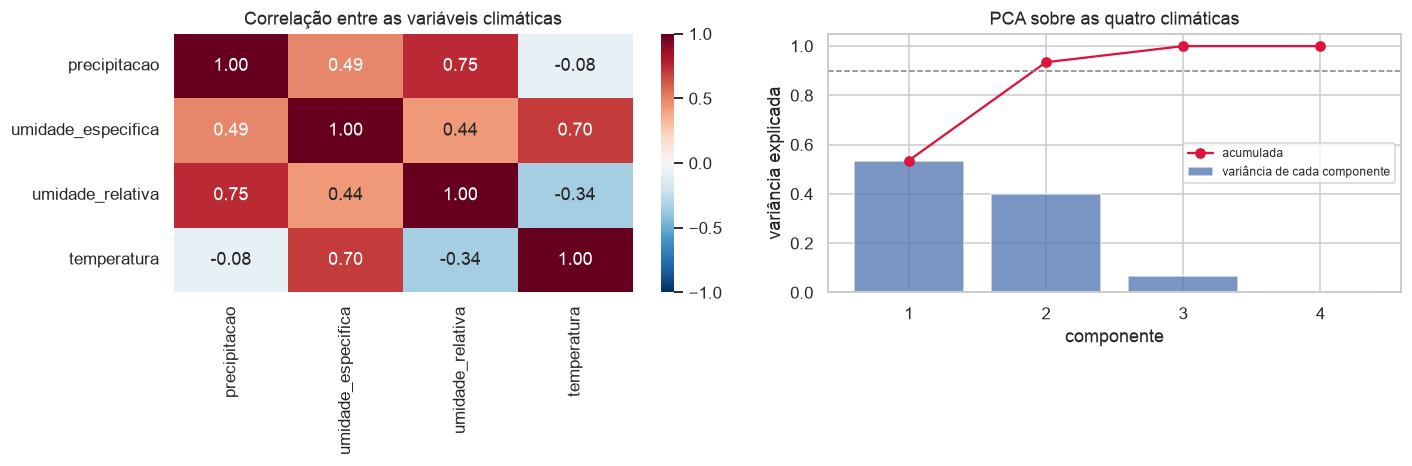

Dois componentes já explicam 93.4% da variação climática.


In [13]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.4))

# Correlação entre as próprias preditoras: mede redundância, não poder preditivo.
sns.heatmap(base_clima[CLIMA].corr(), annot=True, fmt=".2f", center=0,
            cmap="RdBu_r", vmin=-1, vmax=1, ax=eixos[0])
eixos[0].set(title="Correlação entre as variáveis climáticas")

# PCA sobre as climáticas padronizadas. A padronização é obrigatória aqui: sem
# ela a precipitação (milhares de mm) dominaria a temperatura (dezenas de °C).
pca_diag = PCA().fit(StandardScaler().fit_transform(base_clima[CLIMA]))
acumulada = np.cumsum(pca_diag.explained_variance_ratio_)

eixos[1].bar(range(1, 5), pca_diag.explained_variance_ratio_, alpha=.75,
             label="variância de cada componente")
eixos[1].plot(range(1, 5), acumulada, marker="o", color="crimson",
              label="acumulada")
eixos[1].axhline(.9, ls="--", color="0.5", lw=1)   # referência usual de 90%
eixos[1].set(title="PCA sobre as quatro climáticas", xlabel="componente",
             ylabel="variância explicada", xticks=range(1, 5), ylim=(0, 1.05))
eixos[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Dois componentes já explicam {acumulada[1]:.1%} da variação climática.")

Precipitação e umidade relativa andam juntas (**0,75**); umidade específica e
temperatura também (**0,70**). Dois componentes principais concentram a maior
parte da informação — na prática, há cerca de **duas** dimensões climáticas
úteis, não quatro. Isso reforça que o conteúdo informativo da base é menor do
que o número de colunas sugere.

## 3. Clusterização: tendências e cenários discrepantes

O enunciado pede que encontremos tendências de produtividade por meio de
clusterização e identifiquemos outliers. Fazemos isso em dois espaços
diferentes, porque eles respondem perguntas diferentes:

- **espaço clima + rendimento** — agrupa situações de produção parecidas;
- **espaço só clima** — agrupa *regimes climáticos*, independentemente do que
  foi plantado.

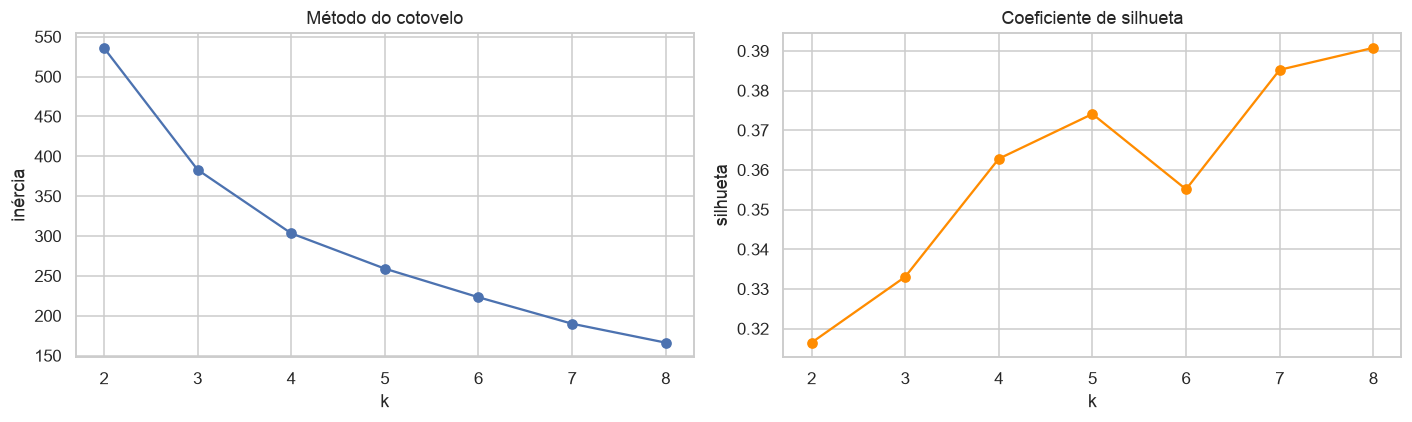

  k=2  silhueta=0.316
  k=3  silhueta=0.333
  k=4  silhueta=0.363
  k=5  silhueta=0.374
  k=6  silhueta=0.355
  k=7  silhueta=0.385
  k=8  silhueta=0.391


In [14]:
# Padronizar antes de agrupar é obrigatório: o K-Means usa distância euclidiana,
# e sem isso o rendimento (dezenas de milhares) anularia a temperatura (dezenas).
escalador = StandardScaler()
X_completo = escalador.fit_transform(df[CLIMA + ["rendimento"]])
X_clima = StandardScaler().fit_transform(base_clima[CLIMA])

# Método do cotovelo + silhueta para escolher k.
faixa_k = range(2, 9)
inercias, silhuetas = [], []
for k in faixa_k:
    km = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10).fit(X_completo)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_completo, km.labels_))

fig, eixos = plt.subplots(1, 2, figsize=(13, 4))
eixos[0].plot(faixa_k, inercias, marker="o")
eixos[0].set(title="Método do cotovelo", xlabel="k", ylabel="inércia")
eixos[1].plot(faixa_k, silhuetas, marker="o", color="darkorange")
eixos[1].set(title="Coeficiente de silhueta", xlabel="k", ylabel="silhueta")
plt.tight_layout()
plt.show()

for k, s in zip(faixa_k, silhuetas):
    print(f"  k={k}  silhueta={s:.3f}")

A silhueta fica na faixa de 0,32–0,39 em todos os valores testados — nenhum `k`
produz separação nítida. Adotamos **k = 4** por corresponder ao número de
culturas, o que permite comparar diretamente o agrupamento com a realidade.

In [15]:
# k=4 no espaço clima + rendimento. n_init=10 roda o algoritmo dez vezes com
# centróides iniciais diferentes e fica com o melhor — o K-Means converge para
# mínimos locais, então uma única inicialização é frágil.
km_completo = KMeans(n_clusters=4, random_state=SEMENTE, n_init=10).fit(X_completo)
df["cluster"] = km_completo.labels_

# Cruza o cluster encontrado com a cultura real: revela o que o algoritmo separou.
cruzamento = pd.crosstab(df["cultura"], df["cluster"])
cruzamento.columns = [f"cluster {i}" for i in cruzamento.columns]
cruzamento

,cluster 0,cluster 1,cluster 2,cluster 3
cultura,,,,
"Cocoa, beans",0,11,17,11
Oil palm fruit,26,3,0,10
"Rice, paddy",0,11,17,11
"Rubber, natural",0,11,17,11


In [16]:
# Agora o mesmo k=4, mas só sobre as 39 condições climáticas distintas.
km_clima = KMeans(n_clusters=4, random_state=SEMENTE, n_init=10).fit(X_clima)

# Cada uma das 39 observações recebe um regime; o mapeamento devolve o regime
# para as quatro linhas (uma por cultura) que compartilham aquela observação.
regime = pd.Series(km_clima.labels_, index=base_clima["obs"].values, name="regime")
df["regime_climatico"] = df["obs"].map(regime)

print("Distribuição das culturas pelos regimes climáticos:")
print(pd.crosstab(df["cultura"], df["regime_climatico"]).to_string())

Distribuição das culturas pelos regimes climáticos:
regime_climatico  0   1   2  3
cultura                       
Cocoa, beans      4  10  17  8
Oil palm fruit    4  10  17  8
Rice, paddy       4  10  17  8
Rubber, natural   4  10  17  8


Os dois cruzamentos contam histórias diferentes, e ambas são informativas.

No espaço **clima + rendimento**, o óleo de palma se isola quase inteiro no
cluster 0 — sua escala de rendimento é tão distinta que domina a distância
euclidiana. As outras três culturas se distribuem de forma idêntica pelos
clusters restantes: o algoritmo está separando *condições climáticas*, não
culturas.

No espaço **só clima**, as quatro culturas se distribuem exatamente igual pelos
quatro regimes — o que já era esperado, já que compartilham o mesmo clima. Esses
grupos são a informação útil: são **quatro regimes climáticos** recorrentes na
região da fazenda.

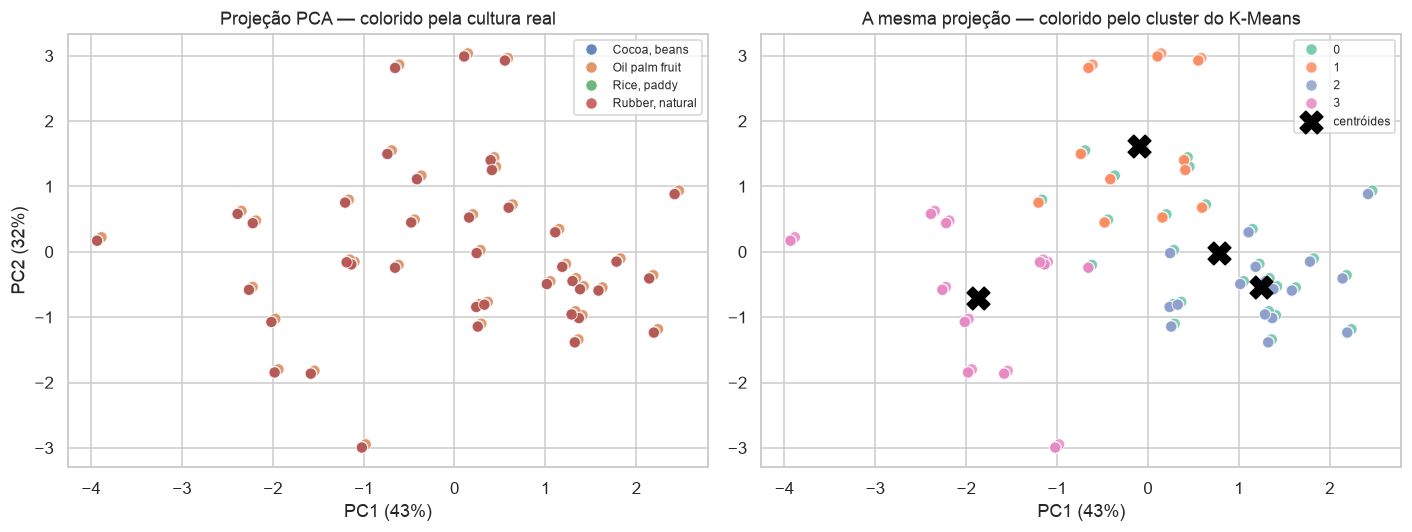

In [17]:
# Reduz as cinco dimensões (4 climáticas + rendimento) a duas, só para poder
# desenhar os clusters num plano e comparar com a cultura real.
pca = PCA(n_components=2, random_state=SEMENTE)
proj = pca.fit_transform(X_completo)
df["pc1"], df["pc2"] = proj[:, 0], proj[:, 1]

# Mesma projeção nos dois painéis, colorida de dois jeitos: pela cultura real e
# pelo cluster. A comparação mostra o que o K-Means de fato capturou.
fig, eixos = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="pc1", y="pc2", hue="cultura", s=55,
                alpha=.85, ax=eixos[0])
eixos[0].set(title="Projeção PCA — colorido pela cultura real",
             xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%})",
             ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
eixos[0].legend(fontsize=8, title=None)

sns.scatterplot(data=df, x="pc1", y="pc2", hue="cluster", palette="Set2",
                s=55, alpha=.85, ax=eixos[1])
eixos[1].scatter(*pca.transform(km_completo.cluster_centers_).T,
                 marker="X", s=220, c="black", label="centróides")
eixos[1].set(title="A mesma projeção — colorido pelo cluster do K-Means",
             xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%})", ylabel="")
eixos[1].legend(fontsize=8, title=None)

plt.tight_layout()
plt.show()

### 3.1 Cenários discrepantes (outliers)

Procuramos outliers de duas formas independentes. A primeira, **DBSCAN**, é
baseada em densidade e não exige definir o número de grupos. A segunda usa o
desvio em relação à média **da própria cultura** — necessária justamente porque
as escalas são muito diferentes: um rendimento de 12.000 é altíssimo para cacau
e baixíssimo para óleo de palma.

In [18]:
# Varre o raio de vizinhança do DBSCAN. Não existe um eps "certo" a priori, e o
# comportamento ao longo da varredura já diz se o método serve para esta base.
print("DBSCAN — sensibilidade ao raio de vizinhança:")
for eps in (0.6, 0.8, 1.0, 1.2, 1.5):
    rotulos = DBSCAN(eps=eps, min_samples=4).fit_predict(X_completo)
    ruido = int((rotulos == -1).sum())              # rótulo -1 = ponto de ruído
    grupos = len(set(rotulos)) - (1 if ruido else 0)  # desconta o -1 da contagem
    print(f"  eps={eps:<4} → {grupos} grupos densos, "
          f"{ruido:>3} pontos de ruído ({ruido / len(df):.0%})")

DBSCAN — sensibilidade ao raio de vizinhança:
  eps=0.6  → 6 grupos densos,  98 pontos de ruído (63%)
  eps=0.8  → 7 grupos densos,  62 pontos de ruído (40%)
  eps=1.0  → 4 grupos densos,  48 pontos de ruído (31%)
  eps=1.2  → 5 grupos densos,  26 pontos de ruído (17%)
  eps=1.5  → 2 grupos densos,   4 pontos de ruído (3%)


O DBSCAN é instável nesta base: com `eps=0.8` ele classifica 40% dos pontos como
ruído, o que não é um resultado útil. A causa é a mesma de sempre — quatro
nuvens de escalas diferentes e apenas 39 pontos por cultura, densidade baixa
demais para o método. Registramos o resultado e usamos o critério estatístico
por cultura como fonte principal.

In [19]:
# Desvio em relação à média da própria cultura, em desvios-padrão.
df["z_na_cultura"] = df.groupby("cultura")["rendimento"].transform(
    lambda s: (s - s.mean()) / s.std())

outliers = df.loc[df["z_na_cultura"].abs() > 2,
                  ["cultura", *CLIMA, "rendimento", "z_na_cultura", "obs"]]
print(f"Cenários discrepantes (|z| > 2 dentro da cultura): {len(outliers)}\n")
outliers.sort_values("z_na_cultura")

Cenários discrepantes (|z| > 2 dentro da cultura): 3



,cultura,precipitacao,umidade_especifica,umidade_relativa,temperatura,rendimento,z_na_cultura,obs
56,Oil palm fruit,"2,362.80",18.70,84.03,26.79,142425,-2.24,17
116,"Rice, paddy","2,109.34",18.51,83.52,26.72,42550,2.18,38
27,"Cocoa, beans","3,085.79",18.34,86.10,26.03,13056,2.39,27


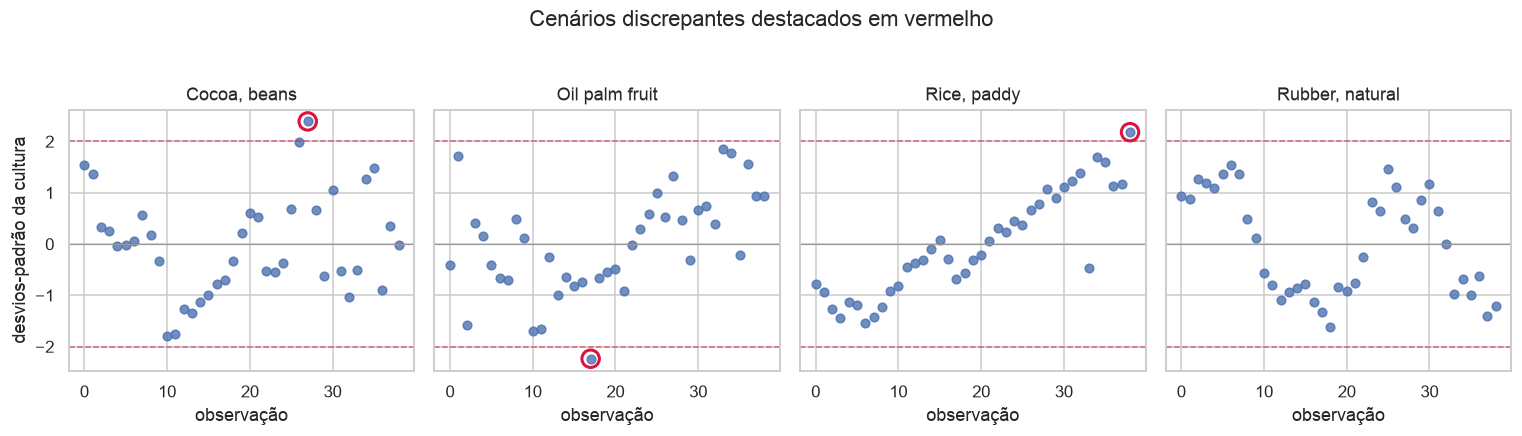

In [20]:
# Um painel por cultura, com o eixo Y compartilhado (sharey) — é o que permite
# comparar os desvios entre culturas de escalas tão diferentes.
fig, eixos = plt.subplots(1, 4, figsize=(14, 3.8), sharey=True)

for eixo, (cultura, g) in zip(eixos, df.groupby("cultura")):
    eixo.scatter(g["obs"], g["z_na_cultura"], s=32, alpha=.8)

    # Círculo vazado em volta de quem passou de dois desvios-padrão.
    discrepantes = g[g["z_na_cultura"].abs() > 2]
    eixo.scatter(discrepantes["obs"], discrepantes["z_na_cultura"],
                 s=130, facecolors="none", edgecolors="crimson", lw=2)

    for limite in (-2, 2):                        # faixas de corte
        eixo.axhline(limite, ls="--", color="crimson", lw=1, alpha=.6)
    eixo.axhline(0, color="0.6", lw=0.8)          # média da cultura
    eixo.set(title=cultura, xlabel="observação")

eixos[0].set_ylabel("desvios-padrão da cultura")
plt.suptitle("Cenários discrepantes destacados em vermelho", y=1.04)
plt.tight_layout()
plt.show()

Três cenários discrepantes, um por cultura afetada:

| Cultura | Rendimento | Desvio | Leitura |
|---|---|---|---|
| Cacau | 13.056 | **+2,39 σ** | melhor safra da série, sob a maior precipitação registrada (3.085 mm/dia) |
| Óleo de palma | 142.425 | **−2,24 σ** | pior safra, na observação de maior umidade específica (18,70 g/kg) |
| Arroz | 42.550 | **+2,18 σ** | melhor safra, e também a última da série — coerente com a tendência de alta |

Nenhum deles parece erro de medição: os três são explicáveis pelas condições da
própria linha. Por isso **mantemos todos na modelagem** — removê-los seria
descartar justamente os extremos que o cliente mais precisa antecipar.

## 4. Modelos preditivos

Cinco algoritmos diferentes, todos sob o mesmo protocolo.

**Boas práticas adotadas:**

1. **Divisão estratificada por cultura** — as quatro culturas aparecem na mesma
   proporção em treino e teste.
2. **Pré-processamento dentro do pipeline** — o `StandardScaler` e o
   `OneHotEncoder` são ajustados apenas no treino, a cada partição da validação
   cruzada. Isso evita vazamento de informação do teste para o treino.
3. **Escalonamento do alvo para o SVR** — modelos baseados em distância exigem
   alvo em escala comparável. Mostramos adiante o que acontece quando isso é
   esquecido.
4. **Validação cruzada 5-fold** além do teste único, para separar desempenho
   real de sorte na divisão.
5. **Comparação obrigatória contra um baseline** — sem ele, não há como saber se
   o modelo aprendeu algo.

In [21]:
X = df[["cultura", *CLIMA]]   # preditoras: a cultura mais as quatro climáticas
y = df["rendimento"]          # alvo

# stratify garante que as quatro culturas apareçam na mesma proporção em treino e
# teste. Sem isso, com só 39 registros por cultura, uma delas poderia ficar
# sub-representada no teste e distorcer as métricas.
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=SEMENTE, stratify=df["cultura"])

print(f"Treino: {len(X_treino)} registros | Teste: {len(X_teste)} registros")
print("\nProporção por cultura:")
print(pd.DataFrame({
    "treino": X_treino["cultura"].value_counts(),
    "teste": X_teste["cultura"].value_counts(),
}).to_string())

Treino: 117 registros | Teste: 39 registros

Proporção por cultura:
                 treino  teste
cultura                       
Cocoa, beans         29     10
Oil palm fruit       30      9
Rice, paddy          29     10
Rubber, natural      29     10


In [22]:
# Cultura vira variável indicadora; as climáticas são padronizadas.
preprocessador = ColumnTransformer([
    ("categorica", OneHotEncoder(handle_unknown="ignore"), ["cultura"]),
    ("numerica", StandardScaler(), CLIMA),
])

MODELOS = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=6, min_samples_leaf=3,
                                               random_state=SEMENTE),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                           random_state=SEMENTE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                                   learning_rate=0.05,
                                                   random_state=SEMENTE),
    # O alvo varia de 5 mil a 200 mil: sem escalonar, o SVR não converge para
    # nada útil. TransformedTargetRegressor padroniza o alvo no treino e
    # desfaz a transformação na predição.
    "SVR (RBF)": TransformedTargetRegressor(
        regressor=SVR(C=10.0, epsilon=0.05), transformer=StandardScaler()),
}

print(f"{len(MODELOS)} algoritmos distintos configurados.")

5 algoritmos distintos configurados.


In [23]:
def avaliar(nome, estimador):
    """Treina, mede no teste e roda validação cruzada sobre a base inteira."""
    # O pré-processador entra DENTRO do pipeline de propósito: assim ele é
    # ajustado só com os dados de treino de cada partição, nunca com o teste.
    pipe = Pipeline([("pre", preprocessador), ("modelo", estimador)])
    pipe.fit(X_treino, y_treino)
    previsto = pipe.predict(X_teste)

    # Validação cruzada em 5 partições, além do teste único: separa desempenho
    # real de sorte na divisão. shuffle embaralha antes de particionar.
    cv = cross_val_score(pipe, X, y, cv=KFold(5, shuffle=True, random_state=SEMENTE),
                         scoring="r2")
    return pipe, previsto, {
        "modelo": nome,
        "R²": r2_score(y_teste, previsto),
        "RMSE": root_mean_squared_error(y_teste, previsto),
        "MAE": mean_absolute_error(y_teste, previsto),
        "MAPE %": mean_absolute_percentage_error(y_teste, previsto) * 100,
        "R² CV (média)": cv.mean(),
        "R² CV (desvio)": cv.std(),
    }

# Roda os cinco sob exatamente o mesmo protocolo e guarda modelo e previsões,
# que serão reaproveitados nas análises por cultura mais adiante.
ajustados, previsoes, linhas = {}, {}, []
for nome, estimador in MODELOS.items():
    ajustados[nome], previsoes[nome], metricas = avaliar(nome, estimador)
    linhas.append(metricas)

resultados = pd.DataFrame(linhas).set_index("modelo").sort_values("R²", ascending=False)
resultados.round(4)

,R²,RMSE,MAE,MAPE %,R² CV (média),R² CV (desvio)
modelo,,,,,,
Regressão Linear,0.98,"9,512.69","5,820.41",17.83,0.99,0.01
Árvore de Decisão,0.98,"9,801.43","4,758.66",11.36,0.98,0.01
Random Forest,0.98,"10,029.60","5,228.61",11.38,0.99,0.01
Gradient Boosting,0.98,"10,058.53","5,519.62",11.82,0.99,0.00
SVR (RBF),0.92,"19,524.85","9,749.54",41.07,0.94,0.03


### 4.1 O baseline que muda a leitura da tabela

Quatro dos cinco modelos passam de 0,98 de R², e até o SVR chega a 0,92. Antes
de comemorar, é preciso responder: **quanto vale um chute informado?**

O baseline mais ingênuo possível aqui é ignorar o clima por completo e prever
sempre a média histórica daquela cultura.

In [24]:
# O baseline: a média de treino de cada cultura vira a previsão para todas as
# linhas de teste daquela cultura. Nenhuma variável climática é consultada.
media_por_cultura = y_treino.groupby(X_treino["cultura"]).mean()
previsao_baseline = X_teste["cultura"].map(media_por_cultura)

baseline = pd.Series({
    "R²": r2_score(y_teste, previsao_baseline),
    "RMSE": root_mean_squared_error(y_teste, previsao_baseline),
    "MAE": mean_absolute_error(y_teste, previsao_baseline),
    "MAPE %": mean_absolute_percentage_error(y_teste, previsao_baseline) * 100,
}, name="BASELINE — média da cultura")

# Junta os cinco modelos e o baseline na mesma tabela, para leitura direta.
comparacao = pd.concat([resultados.drop(columns=["R² CV (média)", "R² CV (desvio)"]),
                        baseline.to_frame().T])

# Ganho percentual sobre o baseline: positivo = o modelo erra menos que o chute.
comparacao["ganho MAPE vs baseline"] = (
    (baseline["MAPE %"] - comparacao["MAPE %"]) / baseline["MAPE %"] * 100)
comparacao.round(3)

,R²,RMSE,MAE,MAPE %,ganho MAPE vs baseline
Regressão Linear,0.98,"9,512.69","5,820.41",17.83,-45.45
Árvore de Decisão,0.98,"9,801.43","4,758.66",11.36,7.30
Random Forest,0.98,"10,029.60","5,228.61",11.38,7.17
Gradient Boosting,0.98,"10,058.53","5,519.62",11.82,3.56
SVR (RBF),0.92,"19,524.85","9,749.54",41.07,-235.05
BASELINE — média da cultura,0.98,"8,700.71","4,961.48",12.26,0.00


O baseline atinge **R² = 0,9842** e **RMSE = 8.701** — melhor que os cinco
modelos, sem exceção. O RMSE mais próximo é o da Regressão Linear, com 9.513.

Um "modelo" que não olha para nenhuma variável climática vence todos os
algoritmos na métrica em que todos pareciam excelentes. Isso não é um defeito
dos algoritmos: é a prova de que **o R² global, nesta base, mede apenas a
capacidade de distinguir as culturas** — coisa que a variável `cultura` já
entrega de graça.

Repare também no MAPE: a Regressão Linear (17,8%) e o SVR (41,1%) são
*piores* que o baseline (12,3%) no erro percentual. Só os três modelos baseados
em árvores conseguem ficar abaixo dele, e por margem estreita.

### 4.2 Medindo o que interessa: acerto dentro de cada cultura

Se o R² global está saturado pela diferença entre culturas, precisamos de uma
métrica que olhe para dentro delas. Duas servem:

- **R² por cultura** — se for próximo de zero, o modelo não fez melhor que
  prever a média daquele grupo;
- **MAPE** — erro percentual, comparável entre escalas muito diferentes.

In [25]:
# R² recalculado dentro de cada cultura. Como o R² compara o modelo com a média
# do próprio grupo avaliado, aqui a referência passa a ser a média DAQUELA
# cultura — e não a média geral, que é o que inflava o número anterior.
r2_interno = {}
for nome, previsto in previsoes.items():
    aux = X_teste.assign(real=y_teste.values, previsto=previsto)
    r2_interno[nome] = {
        cultura: r2_score(g["real"], g["previsto"])
        for cultura, g in aux.groupby("cultura")
    }

pd.DataFrame(r2_interno).T.round(3)

,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
Regressão Linear,0.06,-0.20,-0.25,-5.41
Árvore de Decisão,-0.38,-0.37,0.24,0.44
Random Forest,0.04,-0.41,-0.11,0.59
Gradient Boosting,0.06,-0.43,0.03,0.29
SVR (RBF),-14.18,-4.08,-0.24,-59.39


In [26]:
# MAPE por cultura: erro percentual, portanto comparável entre escalas.
mape_interno = {}
for nome, previsto in previsoes.items():
    aux = X_teste.assign(real=y_teste.values, previsto=previsto)
    mape_interno[nome] = {
        cultura: (abs(g["real"] - g["previsto"]) / g["real"]).mean() * 100
        for cultura, g in aux.groupby("cultura")
    }

# O baseline entra na mesma tabela — é a linha de referência de toda a análise.
aux_base = X_teste.assign(real=y_teste.values, previsto=previsao_baseline.values)
mape_interno["BASELINE"] = {
    cultura: (abs(g["real"] - g["previsto"]) / g["real"]).mean() * 100
    for cultura, g in aux_base.groupby("cultura")
}

tabela_mape = pd.DataFrame(mape_interno).T
tabela_mape["média"] = tabela_mape.mean(axis=1)   # média simples entre culturas
tabela_mape.round(2).sort_values("média")          # menor erro no topo

,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural",média
Árvore de Decisão,13.85,8.49,10.88,11.94,11.29
Random Forest,12.34,9.25,13.33,10.39,11.33
Gradient Boosting,13.61,9.76,12.95,10.77,11.77
BASELINE,13.75,8.66,10.11,16.16,12.17
Regressão Linear,12.67,9.34,12.60,35.85,17.62
SVR (RBF),44.94,13.67,13.20,89.72,40.38


Agora o quadro fica honesto. O R² medido dentro de cada cultura fica **próximo
de zero, e frequentemente negativo** — um R² negativo significa literalmente que
o modelo erra mais do que erraria chutando a média daquele grupo.

O MAPE conta a mesma história com números mais palatáveis: a Árvore de Decisão,
melhor colocada, fica em **11,3%** de erro médio contra **12,2%** do baseline.
Há ganho, mas é marginal — cerca de 7% do erro, não uma transformação. E ele não
é uniforme: na borracha o modelo melhora bastante (16,2% → 11,9%), enquanto no
arroz **piora** (10,1% → 10,9%).

Melhor modelo por MAPE: Árvore de Decisão (11.36%)
Melhor modelo por R²  : Regressão Linear (0.9812) — critério que descartamos


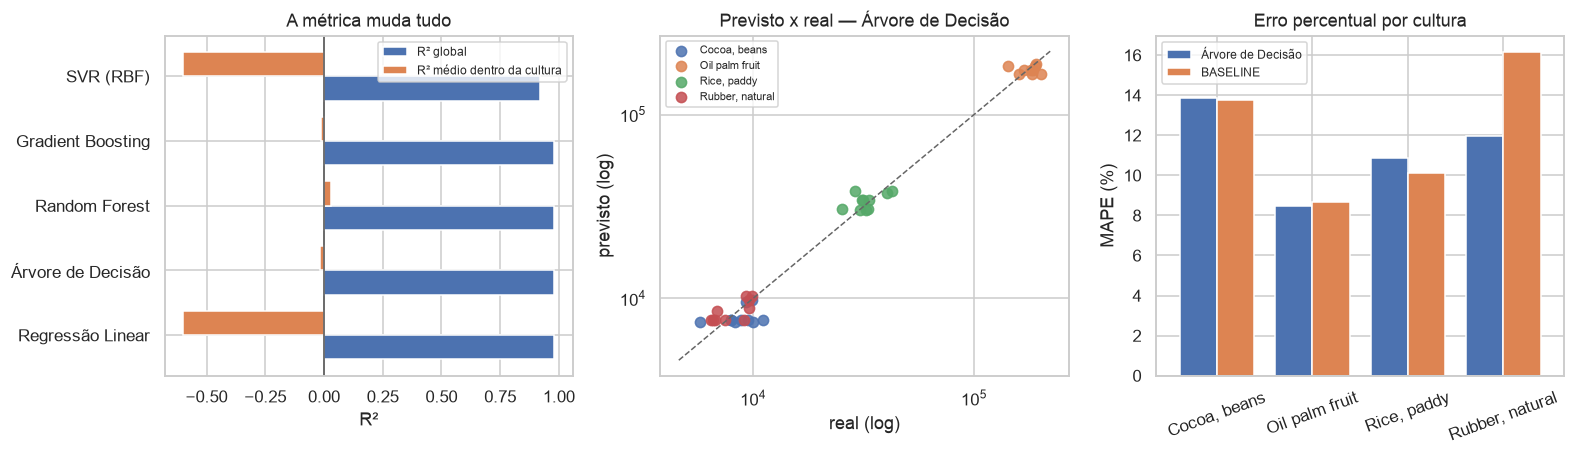

In [27]:
# Coerência com o argumento da seção: o melhor modelo é o de menor MAPE, não o
# de maior R² — que já mostramos ser uma métrica saturada nesta base.
melhor = resultados["MAPE %"].idxmin()
print(f"Melhor modelo por MAPE: {melhor} ({resultados.loc[melhor, 'MAPE %']:.2f}%)")
print(f"Melhor modelo por R²  : {resultados['R²'].idxmax()} "
      f"({resultados['R²'].max():.4f}) — critério que descartamos")

fig, eixos = plt.subplots(1, 3, figsize=(14.5, 4.3))

# 1. R² global x R² dentro da cultura
comp = pd.DataFrame({
    "R² global": resultados["R²"],
    "R² médio dentro da cultura": pd.DataFrame(r2_interno).T.mean(axis=1),
}).clip(lower=-0.6)
comp.plot(kind="barh", ax=eixos[0], width=.75)
eixos[0].axvline(0, color="0.3", lw=1)
eixos[0].set(title="A métrica muda tudo", xlabel="R²", ylabel="")
eixos[0].legend(fontsize=8)

# 2. Previsto x real do melhor modelo
aux = X_teste.assign(real=y_teste.values, previsto=previsoes[melhor])
for cultura, g in aux.groupby("cultura"):
    eixos[1].scatter(g["real"], g["previsto"], s=45, alpha=.85, label=cultura)
lim = [y_teste.min() * .8, y_teste.max() * 1.1]
eixos[1].plot(lim, lim, ls="--", color="0.4", lw=1)
eixos[1].set(xscale="log", yscale="log", title=f"Previsto x real — {melhor}",
             xlabel="real (log)", ylabel="previsto (log)")
eixos[1].legend(fontsize=7)

# 3. MAPE por cultura, modelo x baseline
tabela_mape.drop(columns="média").T[[melhor, "BASELINE"]].plot(
    kind="bar", ax=eixos[2], width=.78)
eixos[2].set(title="Erro percentual por cultura", ylabel="MAPE (%)", xlabel="")
eixos[2].tick_params(axis="x", rotation=20)
eixos[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 4.3 O que os modelos consideram importante

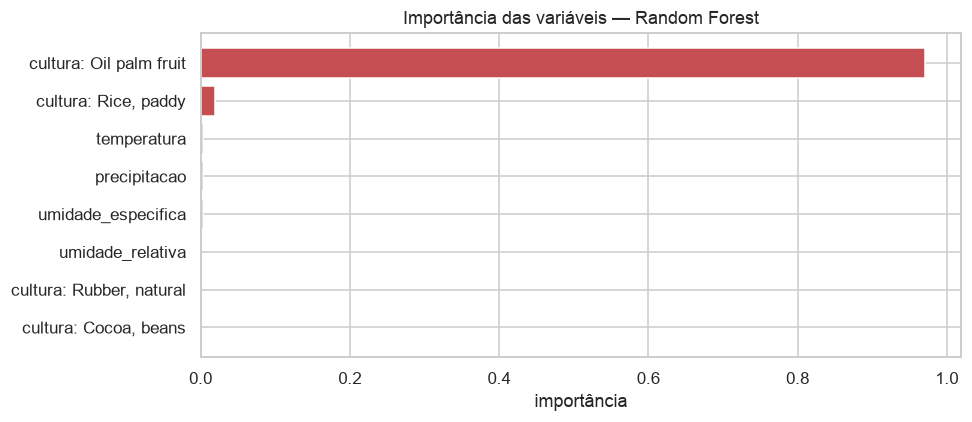

Peso total das indicadoras de cultura: 99.0%
Peso total das variáveis climáticas:   1.0%


In [28]:
floresta = ajustados["Random Forest"]

# get_feature_names_out devolve os nomes já expandidos pelo OneHotEncoder — uma
# coluna indicadora por cultura, mais as quatro climáticas.
nomes = floresta.named_steps["pre"].get_feature_names_out()
importancias = pd.Series(
    floresta.named_steps["modelo"].feature_importances_, index=nomes
).sort_values()

# Remove o prefixo do ColumnTransformer ("cat__", "num__") para o gráfico.
nomes_limpos = [n.split("__")[-1].replace("cultura_", "cultura: ")
                for n in importancias.index]

plt.figure(figsize=(9, 4))
# Vermelho para as indicadoras de cultura, azul para as climáticas: o contraste
# de cor é o que faz o resultado saltar aos olhos.
cores = ["#c44e52" if "cultura" in n else "#4c72b0" for n in nomes_limpos]
plt.barh(nomes_limpos, importancias.values, color=cores)
plt.title("Importância das variáveis — Random Forest")
plt.xlabel("importância")
plt.tight_layout()
plt.show()

peso_cultura = importancias[[n for n in importancias.index if "cultura" in n]].sum()
print(f"Peso total das indicadoras de cultura: {peso_cultura:.1%}")
print(f"Peso total das variáveis climáticas:   {1 - peso_cultura:.1%}")

Confirmação final e direta: as indicadoras de cultura concentram a quase
totalidade da importância. O modelo aprendeu, essencialmente, uma tabela de
consulta de médias por cultura.

### 4.4 Uma demonstração de boa prática: o SVR sem escalonamento do alvo

Vale mostrar o que teria acontecido se o alvo não tivesse sido padronizado. É o
tipo de erro silencioso que passa despercebido em um pipeline mal montado.

In [29]:
# Mesmo SVR, mesmos dados, mesmo C — a única diferença é não envolver o
# estimador no TransformedTargetRegressor, ou seja, não padronizar o alvo.
svr_sem_escala = Pipeline([("pre", preprocessador), ("modelo", SVR(C=10.0))])
svr_sem_escala.fit(X_treino, y_treino)
r2_ruim = r2_score(y_teste, svr_sem_escala.predict(X_teste))
r2_bom = resultados.loc["SVR (RBF)", "R²"]   # o da tabela, com alvo escalonado

print(f"SVR sem escalonar o alvo : R² = {r2_ruim:7.4f}")
print(f"SVR com alvo escalonado  : R² = {r2_bom:7.4f}")
print(f"\nDiferença: {r2_bom - r2_ruim:.2f} pontos de R² — o mesmo algoritmo,")
print("apenas com o pré-processamento correto.")

SVR sem escalonar o alvo : R² = -0.1779
SVR com alvo escalonado  : R² =  0.9206

Diferença: 1.10 pontos de R² — o mesmo algoritmo,
apenas com o pré-processamento correto.


## 5. Conclusões

### O que a base permite responder

**A cultura plantada define o patamar do rendimento.** Sozinha, ela explica
98,76% da variância. Para a fazenda, isso significa que a decisão de *o que*
plantar pesa incomparavelmente mais que a variação climática de um ano para
outro — dentro da faixa de clima observada, que é estreita.

**Existem quatro regimes climáticos recorrentes** na região, identificados pela
clusterização sobre as variáveis climáticas. Eles são a base para agrupar anos
semelhantes e comparar desempenho safra a safra.

**Três cenários discrepantes** foram identificados e explicados: a melhor safra
de cacau coincide com a maior precipitação da série; a pior de óleo de palma,
com a maior umidade específica; a melhor de arroz é a última observação, no topo
de uma tendência de alta.

**Culturas reagem ao clima em direções opostas.** O arroz responde
positivamente a calor e umidade (0,70 e 0,61); a borracha, negativamente (−0,43
e −0,41). Qualquer modelo agregado que ignore a cultura anula esses efeitos.

### Pontos fortes do trabalho

- Cinco algoritmos comparados sob protocolo idêntico, com pré-processamento
  encapsulado em pipeline — sem vazamento de dados entre treino e teste.
- Avaliação em três métricas complementares (R², RMSE/MAE e MAPE) mais validação
  cruzada, em vez de uma única medida.
- **Comparação obrigatória com baseline**, que foi o que revelou o problema real
  da base.
- Métrica de acerto medida *dentro* de cada cultura, que é o que efetivamente
  responde à pergunta do cliente.

### Limitações — e elas são relevantes

1. **O R² global engana nesta base.** Um baseline que só prevê a média da
   cultura atinge 0,9842 de R² e 8.701 de RMSE — melhor que os cinco modelos.
   Reportar "R² de 0,98" como resultado seria tecnicamente verdadeiro e
   materialmente enganoso.

2. **Há 39 condições climáticas, não 156.** As quatro culturas compartilham
   exatamente as mesmas medições. O volume efetivo de informação é quatro vezes
   menor do que a contagem de linhas sugere.

3. **Provável correlação espúria por tendência temporal.** O rendimento do arroz
   correlaciona 0,91 com a posição no arquivo, e a umidade específica, 0,80. A
   associação entre os dois pode refletir ganho tecnológico ao longo dos anos,
   não efeito climático. Sem a coluna de data, não é possível separar os dois.

4. **As variáveis climáticas são redundantes.** Dois componentes principais
   concentram a maior parte da variação — há cerca de duas dimensões úteis, não
   quatro.

5. **A faixa climática observada é estreita.** A temperatura varia entre 25,6 °C
   e 26,8 °C — pouco mais de um grau. O modelo não tem base para extrapolar para
   condições fora dessa janela, que são justamente as de maior risco.

### Recomendações para a próxima etapa

| Prioridade | Ação | Por quê |
|---|---|---|
| Alta | Obter a **coluna de data** de cada medição | Sem ela é impossível separar efeito climático de tendência tecnológica |
| Alta | Ampliar a série ou incluir **outras localidades** | 39 pontos por cultura não sustentam um modelo climático confiável |
| Média | Registrar variáveis **agronômicas** (solo, adubação, cultivar, área plantada) | O clima explica pouco; o manejo provavelmente explica muito |
| Média | Adotar **MAPE por cultura** como métrica oficial | É a única comparável entre escalas tão distintas |
| Baixa | Reavaliar modelos por cultura quando houver mais dados | Hoje, com 39 pontos, o R² validado por cultura é negativo |

### Resposta objetiva ao cliente

Com os dados atuais, a previsão prática de rendimento é a **média histórica da
cultura**, com o modelo de árvore aparando cerca de 7% do erro. O erro esperado
fica na casa de **11% a 12%**, conforme a cultura.

Para chegar a uma previsão climática de fato útil, o caminho não passa por um
algoritmo mais sofisticado — os cinco testados já esgotaram o que estes dados
oferecem. Passa por **coletar mais dados**: a data de cada safra, para separar
clima de tendência tecnológica, e variáveis de manejo, que é onde
provavelmente está a explicação que falta.

---

*A Entrega 2, com a comparação de custos de infraestrutura na AWS entre as
regiões de São Paulo e Virgínia do Norte, está no `README.md` do repositório.*